In [1]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from scipy.interpolate import griddata
import re
import xarray as xr

# 1. Déclaration des fonctions 

In [2]:
def read_general_netcdf(filename):
    data = {}
    with xr.open_dataset(filename) as ds:
        for k, v in ds.data_vars.items():
            data[k] = v.values
        for k, v in ds.attrs.items():
            data[k] = v
    return data

def read_data(parameters):
    def imap_norm(intensity_map):
        avg_flux = np.mean(intensity_map)
        return intensity_map / avg_flux - 1.0, avg_flux

    def imap2modes(intensity_map_normalized, lmax):
        modes_complex = hp.sphtfunc.map2alm(intensity_map_normalized, lmax=lmax)
        return modes_complex.real, modes_complex.imag

    def alms2power_spectrum(alms, LMAX):
        #Cette fonction calcule les $\sigma_{l}^2 / \bar{I}$
        the_modes = np.zeros(LMAX)
        the_modes_full = np.zeros((LMAX,LMAX+1))
        for l in range(LMAX):
            for m in range(l+1):
                the_modes_full[l,m] = np.real(alms[hp.sphtfunc.Alm.getidx(LMAX, l, m)]*
                    np.conjugate(alms[hp.sphtfunc.Alm.getidx(LMAX, l, m)]))
                if (m>0):
                    the_modes[l] = the_modes[l] + 2.*the_modes_full[l,m]
                else:          
                    the_modes[l] = the_modes[l] + the_modes_full[l,m]
        the_modes = the_modes / (4.*np.pi)
        return the_modes
    
    LMAX = 30
    illumination_evaluation_radii = 1940.0
    dataset = {}
    intensity_map = parameters["intensity"] * (illumination_evaluation_radii / 10000.0)**2
    intensity_map_normalized, dataset["avg_flux"] = imap_norm(intensity_map)
    dataset["real_modes"], dataset["imag_modes"] = imap2modes(intensity_map_normalized, LMAX)
    complex_modes = dataset["real_modes"] + 1j * dataset["imag_modes"]
    dataset["sigma_l^2"] = alms2power_spectrum(complex_modes, LMAX)
    dataset["sigma_RMS %"] = 100 * np.sqrt(np.sum(dataset["sigma_l^2"]))
    return dataset

def parse_beam_params(filepath):
    beams = []
    keys = {"P0_TW", "THETA_DEG", "PHI_DEG", "FOC_UM"}
    with open(filepath, "r") as f:
        content = f.read()
    for block in re.findall(r"&BEAM(.*?)/", content, re.DOTALL):
        beam = {}
        for key in keys:
            if key == "FOC_UM":
                # capture toute la liste de valeurs sur la ligne (séparées par des virgules)
                match = re.search(rf"{key}\s*=\s*([\-\d\.dDeE,\s]+)", block)
                if match:
                    raw_values = match.group(1).strip().rstrip(",").split(",")
                    beam[key] = [
                        float(v.strip().replace("d", "e").replace("D", "e"))
                        for v in raw_values if v.strip()
                    ]
            else:
                match = re.search(rf"{key}\s*=\s*([\-\d\.dD]+)", block)
                if match:
                    beam[key] = float(match.group(1).replace("d", "e").replace("D", "e"))
        beams.append(beam)
    return beams  # liste de 30 dicts

# 2. Chargement des données

In [3]:
main_dir = "ifriit"

p_in_z1z2_beam_all = read_general_netcdf(main_dir + "/p_in_z1z2_beam_all_opti1tache_sansP0.nc")

dataset = read_data(p_in_z1z2_beam_all)

ifriit_inputs_originale = parse_beam_params("ifriit_inputs_originale_1tache.txt")
ifriit_inputs = parse_beam_params(main_dir + "/ifriit_inputs_opti1tache_sansP0.txt")
NBEAMS = len(ifriit_inputs)

print("Nombre de beams:", NBEAMS)
print("sigma_RMS % = ", dataset["sigma_RMS %"])

Nombre de beams: 30
sigma_RMS % =  0.26409324754495217


# 3. Visualisation de l'intensité 

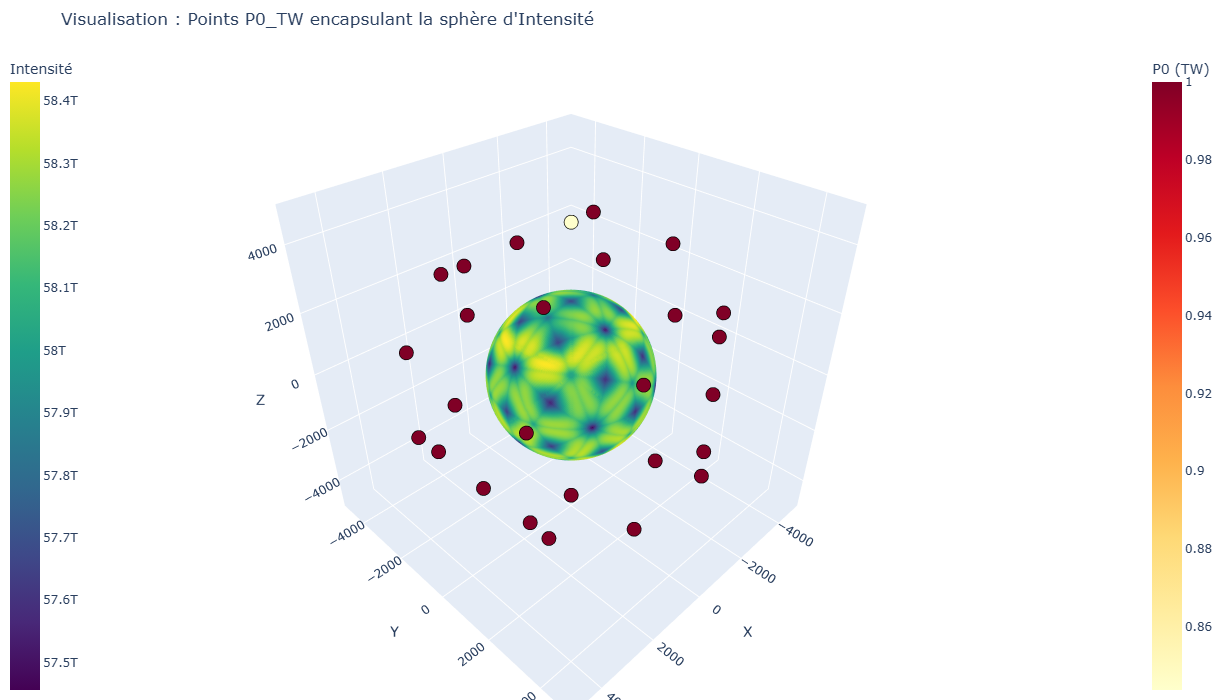

In [4]:
#  Données de la sphère d'INTENSITÉ 
intensity = np.array(p_in_z1z2_beam_all['intensity'])

R_int = 2307.0
R_p0 = 2307.0*2

t_rad = np.array(p_in_z1z2_beam_all['theta'])
p_rad = np.array(p_in_z1z2_beam_all['phi'])
X_int = R_int * np.sin(t_rad) * np.cos(p_rad)
Y_int = R_int * np.sin(t_rad) * np.sin(p_rad)
Z_int = R_int * np.cos(t_rad)

# Données de PUISSANCE P0_TW 

p0_vals = np.array([b['P0_TW'] for b in ifriit_inputs])
t_ifriit_rad = np.radians([b['THETA_DEG'] for b in ifriit_inputs])
p_ifriit_rad = np.radians([b['PHI_DEG'] for b in ifriit_inputs])

X_p0 = R_p0 * np.sin(t_ifriit_rad) * np.cos(p_ifriit_rad)
Y_p0 = R_p0 * np.sin(t_ifriit_rad) * np.sin(p_ifriit_rad)
Z_p0 = R_p0 * np.cos(t_ifriit_rad)

fig = go.Figure()

# sphère d'intensité 
fig.add_trace(go.Scatter3d(
    x=X_int, y=Y_int, z=Z_int,
    mode='markers',
    marker=dict(
        size=3,
        color=intensity,
        colorscale='Viridis',
        opacity=1.0,  
        showscale=True,
        colorbar=dict(title="Intensité", x=-0.1)
    ),
    name="Sphère d'Intensité",
    hoverinfo='skip'
))

# nuage de points P0_TW 
fig.add_trace(go.Scatter3d(
    x=X_p0, y=Y_p0, z=Z_p0,
    mode='markers',
    marker=dict(
        size=8,
        color=p0_vals,
        colorscale='YlOrRd',
        opacity=1.0,
        showscale=True,
        colorbar=dict(title="P0 (TW)", x=1.1),
        line=dict(color='black', width=2)
    ),
    name="Points P0 (Capsule)",
    text=[f"Faisceau P0: {p:.2f} TW" for p in p0_vals],
    hoverinfo='text+x+y+z'
))


fig.add_trace(go.Scatter3d(x=[0], y=[0], z=[0]))

fig.update_layout(
    title="Visualisation : Points P0_TW encapsulant la sphère d'Intensité",
    showlegend=False, 
    scene=dict(
        xaxis=dict(title='X', range=[-R_p0*1.1, R_p0*1.1]), # On utilise le rayon max avec 10% de marge
        yaxis=dict(title='Y', range=[-R_p0*1.1, R_p0*1.1]),
        zaxis=dict(title='Z', range=[-R_p0*1.1, R_p0*1.1]),
        aspectmode='cube'
    ),
    width=900,
    height=700,
    margin=dict(l=0, r=0, b=0, t=50)
)
fig.show()



# 4. Visualisation de la correction

In [5]:
def cart2sph(x, y, z):
    r = np.sqrt(x**2 + y**2 + z**2)
    theta = np.arccos(np.clip(z / r, -1.0, 1.0))
    phi = np.arctan2(y, x)
    return r, theta, phi

idx = np.arange(NBEAMS)

# --- Coordonnées cartésiennes (avant / après) ---
x1 = np.array([ifriit_inputs_originale[i]['FOC_UM'][0] for i in range(NBEAMS)])
y1 = np.array([ifriit_inputs_originale[i]['FOC_UM'][1] for i in range(NBEAMS)])
z1 = np.array([ifriit_inputs_originale[i]['FOC_UM'][2] for i in range(NBEAMS)])

x2 = np.array([ifriit_inputs[i]['FOC_UM'][0] for i in range(NBEAMS)])
y2 = np.array([ifriit_inputs[i]['FOC_UM'][1] for i in range(NBEAMS)])
z2 = np.array([ifriit_inputs[i]['FOC_UM'][2] for i in range(NBEAMS)])

# --- Puissances (avant / après) ---
P0_1 = np.array([ifriit_inputs_originale[i]['P0_TW'] for i in range(NBEAMS)])
P0_2 = np.array([ifriit_inputs[i]['P0_TW'] for i in range(NBEAMS)])

# --- Coordonnées sphériques (avant / après), calculées une seule fois ---
r1, theta1, phi1 = cart2sph(x1, y1, z1)
r2, theta2, phi2 = cart2sph(x2, y2, z2)

# --- Deltas ---
delta_x = x2 - x1
delta_y = y2 - y1
delta_z = z2 - z1
delta_P0 = P0_2 - P0_1
delta_r = r2 - r1
delta_theta = theta2 - theta1
delta_phi = phi2 - phi1

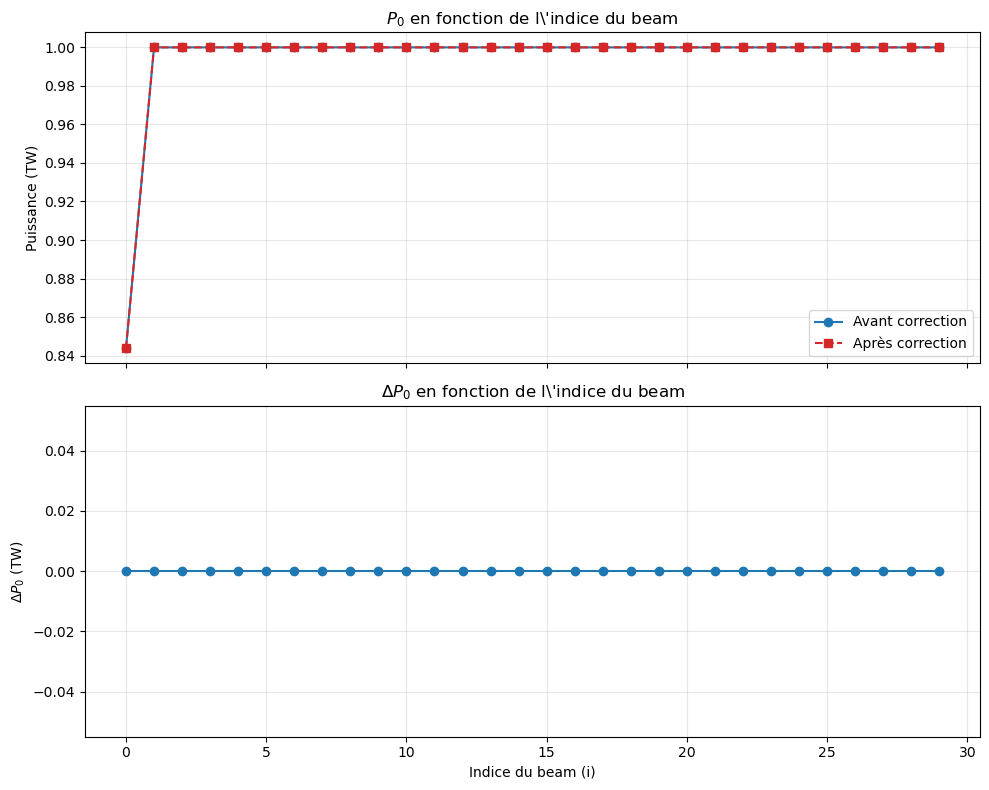

In [6]:
fig, (ax_p, ax_dp) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

ax_p.plot(idx, P0_1, 'o-', color='tab:blue', label='Avant correction')
ax_p.plot(idx, P0_2, 's--', color='tab:red', label='Après correction')
ax_p.set_ylabel(r'Puissance (TW)')
ax_p.set_title(r'$P_0$ en fonction de l\'indice du beam')
ax_p.grid(True, alpha=0.3)
ax_p.legend()

ax_dp.plot(idx, delta_P0, 'o-', color='tab:blue')
ax_dp.set_xlabel('Indice du beam (i)')
ax_dp.set_ylabel(r'$\Delta P_0$ (TW)')
ax_dp.set_title(r'$\Delta P_0$ en fonction de l\'indice du beam')
ax_dp.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

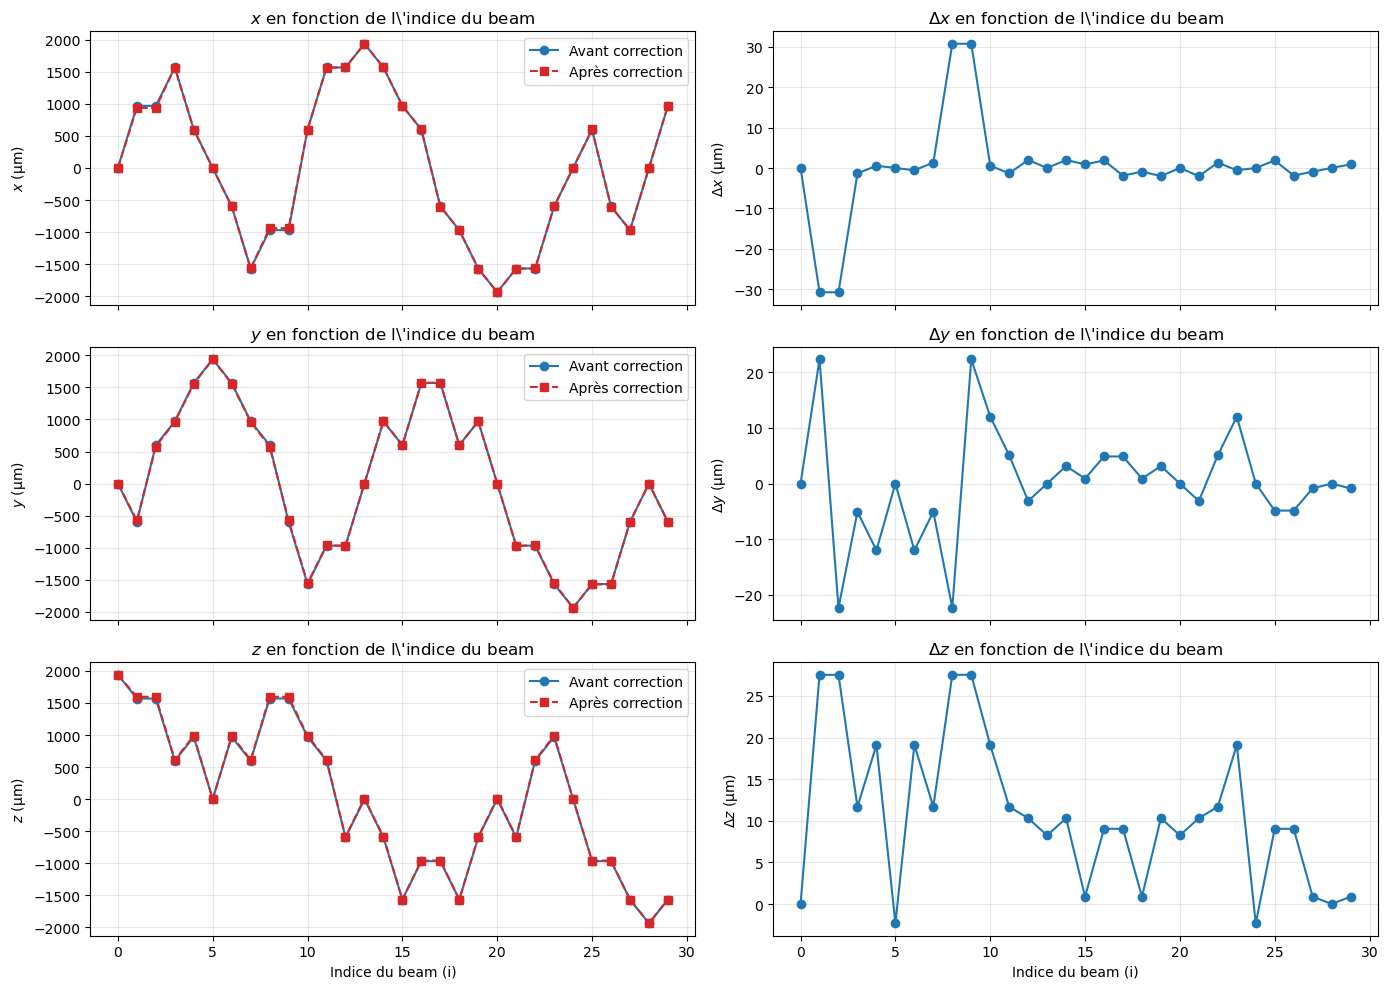

In [7]:
fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=True)
(ax_x, ax_dx), (ax_y, ax_dy), (ax_z, ax_dz) = axes

# x
ax_x.plot(idx, x1, 'o-', color='tab:blue', label='Avant correction')
ax_x.plot(idx, x2, 's--', color='tab:red', label='Après correction')
ax_x.set_ylabel(r'$x$ (µm)')
ax_x.set_title(r'$x$ en fonction de l\'indice du beam')
ax_x.grid(True, alpha=0.3)
ax_x.legend()

ax_dx.plot(idx, delta_x, 'o-', color='tab:blue')
ax_dx.set_ylabel(r'$\Delta x$ (µm)')
ax_dx.set_title(r'$\Delta x$ en fonction de l\'indice du beam')
ax_dx.grid(True, alpha=0.3)

# y
ax_y.plot(idx, y1, 'o-', color='tab:blue', label='Avant correction')
ax_y.plot(idx, y2, 's--', color='tab:red', label='Après correction')
ax_y.set_ylabel(r'$y$ (µm)')
ax_y.set_title(r'$y$ en fonction de l\'indice du beam')
ax_y.grid(True, alpha=0.3)
ax_y.legend()

ax_dy.plot(idx, delta_y, 'o-', color='tab:blue')
ax_dy.set_ylabel(r'$\Delta y$ (µm)')
ax_dy.set_title(r'$\Delta y$ en fonction de l\'indice du beam')
ax_dy.grid(True, alpha=0.3)

# z
ax_z.plot(idx, z1, 'o-', color='tab:blue', label='Avant correction')
ax_z.plot(idx, z2, 's--', color='tab:red', label='Après correction')
ax_z.set_xlabel('Indice du beam (i)')
ax_z.set_ylabel(r'$z$ (µm)')
ax_z.set_title(r'$z$ en fonction de l\'indice du beam')
ax_z.grid(True, alpha=0.3)
ax_z.legend()

ax_dz.plot(idx, delta_z, 'o-', color='tab:blue')
ax_dz.set_xlabel('Indice du beam (i)')
ax_dz.set_ylabel(r'$\Delta z$ (µm)')
ax_dz.set_title(r'$\Delta z$ en fonction de l\'indice du beam')
ax_dz.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

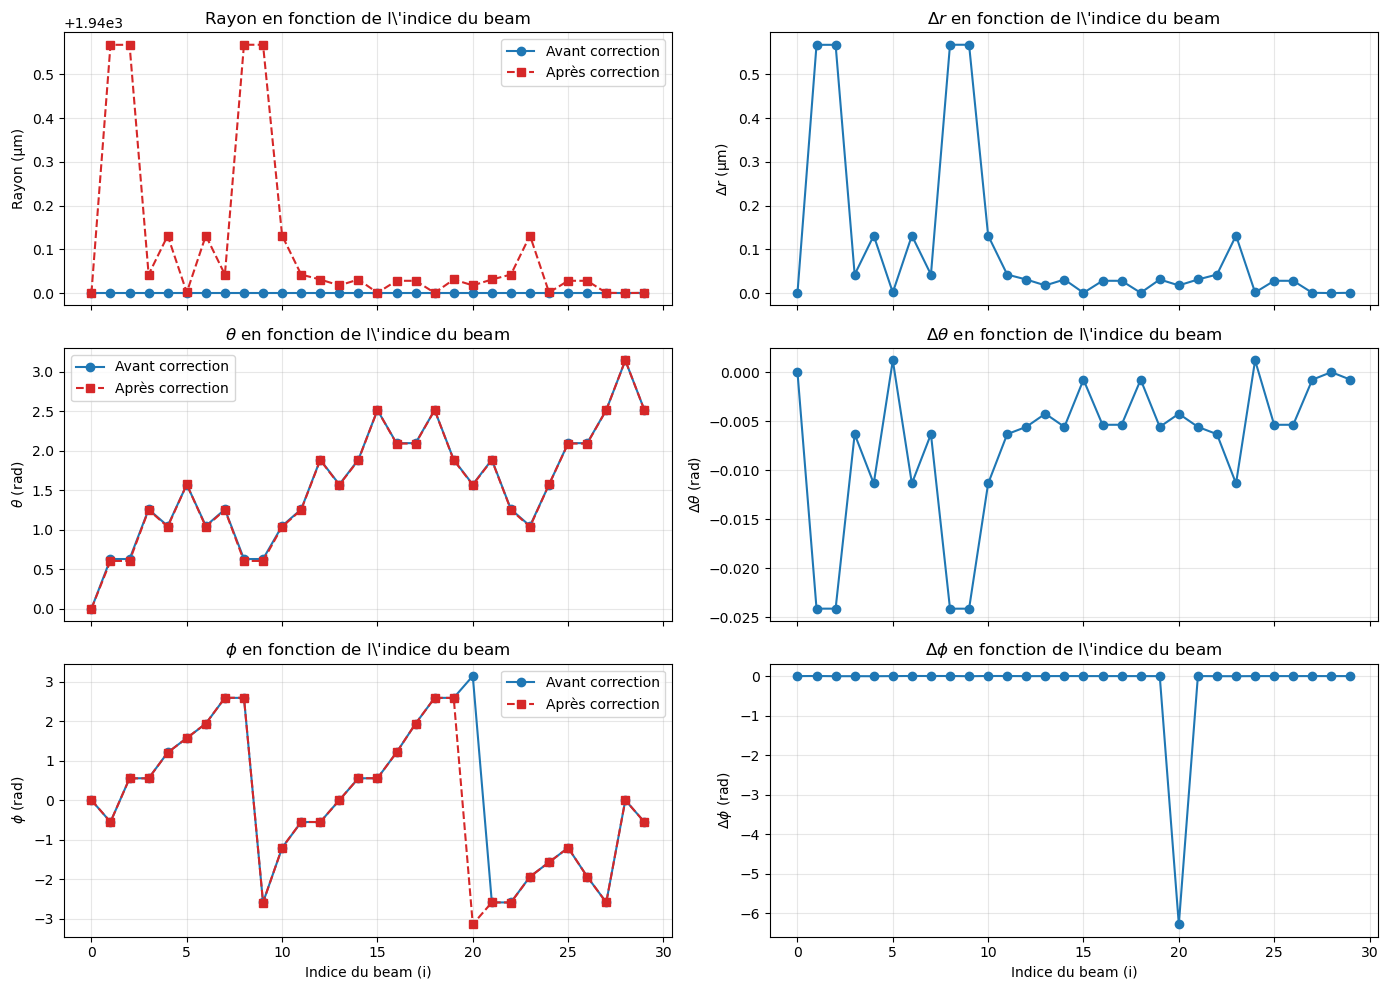

In [8]:
fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=True)
(ax_r, ax_dr), (ax_th, ax_dth), (ax_ph, ax_dph) = axes

# r
ax_r.plot(idx, r1, 'o-', color='tab:blue', label='Avant correction')
ax_r.plot(idx, r2, 's--', color='tab:red', label='Après correction')
ax_r.set_ylabel(r'Rayon (µm)')
ax_r.set_title(r'Rayon en fonction de l\'indice du beam')
ax_r.grid(True, alpha=0.3)
ax_r.legend()

ax_dr.plot(idx, delta_r, 'o-', color='tab:blue')
ax_dr.set_ylabel(r'$\Delta r$ (µm)')
ax_dr.set_title(r'$\Delta r$ en fonction de l\'indice du beam')
ax_dr.grid(True, alpha=0.3)

# theta
ax_th.plot(idx, theta1, 'o-', color='tab:blue', label='Avant correction')
ax_th.plot(idx, theta2, 's--', color='tab:red', label='Après correction')
ax_th.set_ylabel(r'$\theta$ (rad)')
ax_th.set_title(r'$\theta$ en fonction de l\'indice du beam')
ax_th.grid(True, alpha=0.3)
ax_th.legend()

ax_dth.plot(idx, delta_theta, 'o-', color='tab:blue')
ax_dth.set_ylabel(r'$\Delta \theta$ (rad)')
ax_dth.set_title(r'$\Delta \theta$ en fonction de l\'indice du beam')
ax_dth.grid(True, alpha=0.3)

# phi
ax_ph.plot(idx, phi1, 'o-', color='tab:blue', label='Avant correction')
ax_ph.plot(idx, phi2, 's--', color='tab:red', label='Après correction')
ax_ph.set_xlabel('Indice du beam (i)')
ax_ph.set_ylabel(r'$\phi$ (rad)')
ax_ph.set_title(r'$\phi$ en fonction de l\'indice du beam')
ax_ph.grid(True, alpha=0.3)
ax_ph.legend()

ax_dph.plot(idx, delta_phi, 'o-', color='tab:blue')
ax_dph.set_xlabel('Indice du beam (i)')
ax_dph.set_ylabel(r'$\Delta \phi$ (rad)')
ax_dph.set_title(r'$\Delta \phi$ en fonction de l\'indice du beam')
ax_dph.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

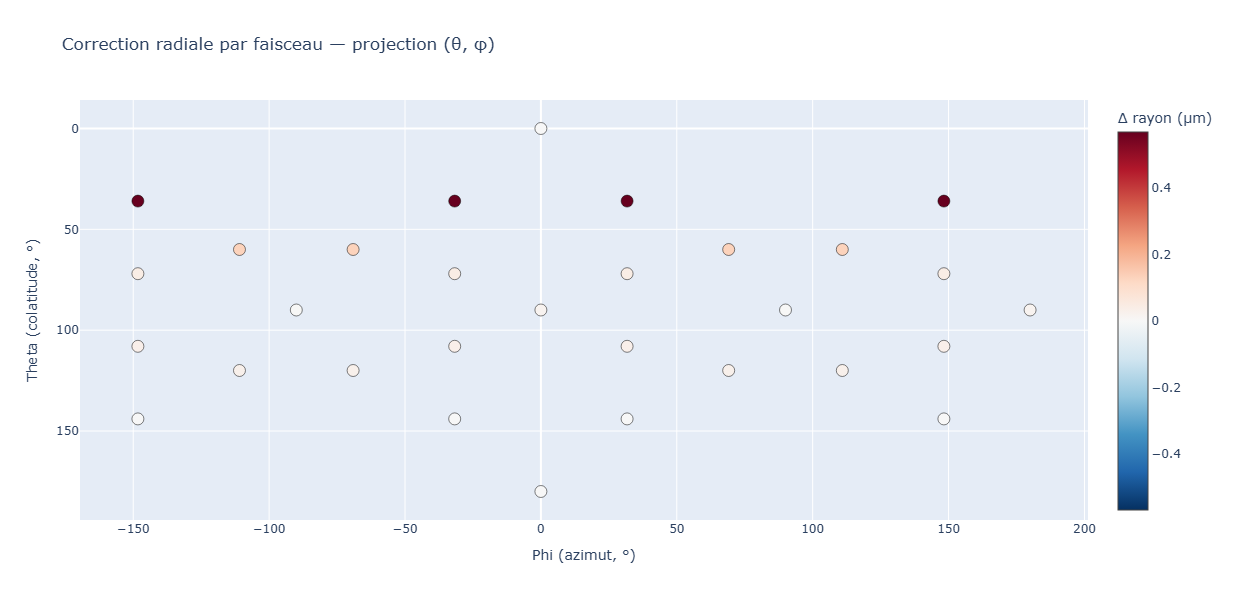

In [9]:
max_abs_delta = np.max(np.abs(delta_r))

fig2 = go.Figure(data=go.Scatter(
    x=np.degrees(phi1),
    y=np.degrees(theta1),
    mode='markers',
    marker=dict(
        size=12,
        color=delta_r,
        colorscale='RdBu_r',
        cmin=-max_abs_delta,
        cmax=max_abs_delta,
        colorbar=dict(title="Δ rayon (µm)"),
        line=dict(color='black', width=0.5)
    ),
    text=[f"Faisceau {i}<br>Δr = {delta_r[i]:.4f} µm<br>r_avant={r1[i]:.8g}<br>r_après={r2[i]:.8g}"
          for i in range(NBEAMS)],
    hoverinfo='text'
))
fig2.update_layout(
    title="Correction radiale par faisceau — projection (θ, φ)",
    xaxis_title="Phi (azimut, °)",
    yaxis_title="Theta (colatitude, °)",
    yaxis=dict(autorange='reversed'),
    width=900,
    height=600
)
fig2.show()

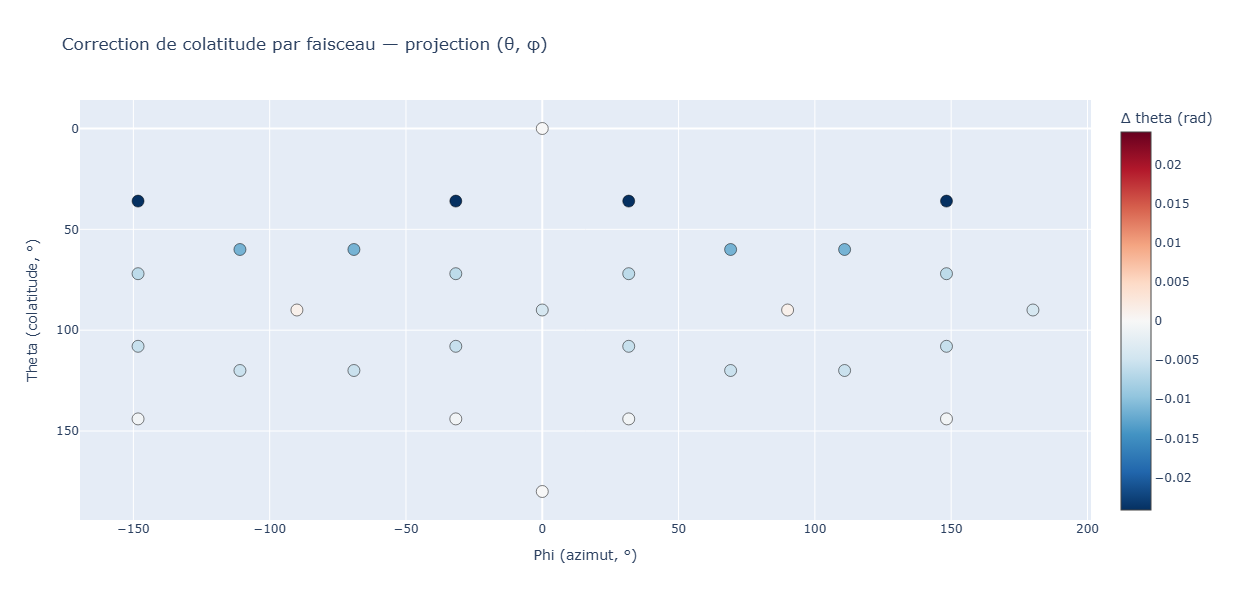

In [10]:
max_abs_delta = np.max(np.abs(delta_theta))

fig2 = go.Figure(data=go.Scatter(
    x=np.degrees(phi1),
    y=np.degrees(theta1),
    mode='markers',
    marker=dict(
        size=12,
        color=delta_theta,
        colorscale='RdBu_r',
        cmin=-max_abs_delta,
        cmax=max_abs_delta,
        colorbar=dict(title="Δ theta (rad)"),
        line=dict(color='black', width=0.5)
    ),
    text=[f"Faisceau {i}<br>Δtheta = {np.degrees(delta_theta[i]):.4f} °<br>theta_avant={np.degrees(theta1[i]):.6g}<br>theta_après={np.degrees(theta2[i]):.6g}"
          for i in range(NBEAMS)],
    hoverinfo='text'
))
fig2.update_layout(
    title="Correction de colatitude par faisceau — projection (θ, φ)",
    xaxis_title="Phi (azimut, °)",
    yaxis_title="Theta (colatitude, °)",
    yaxis=dict(autorange='reversed'),
    width=900,
    height=600
)
fig2.show()

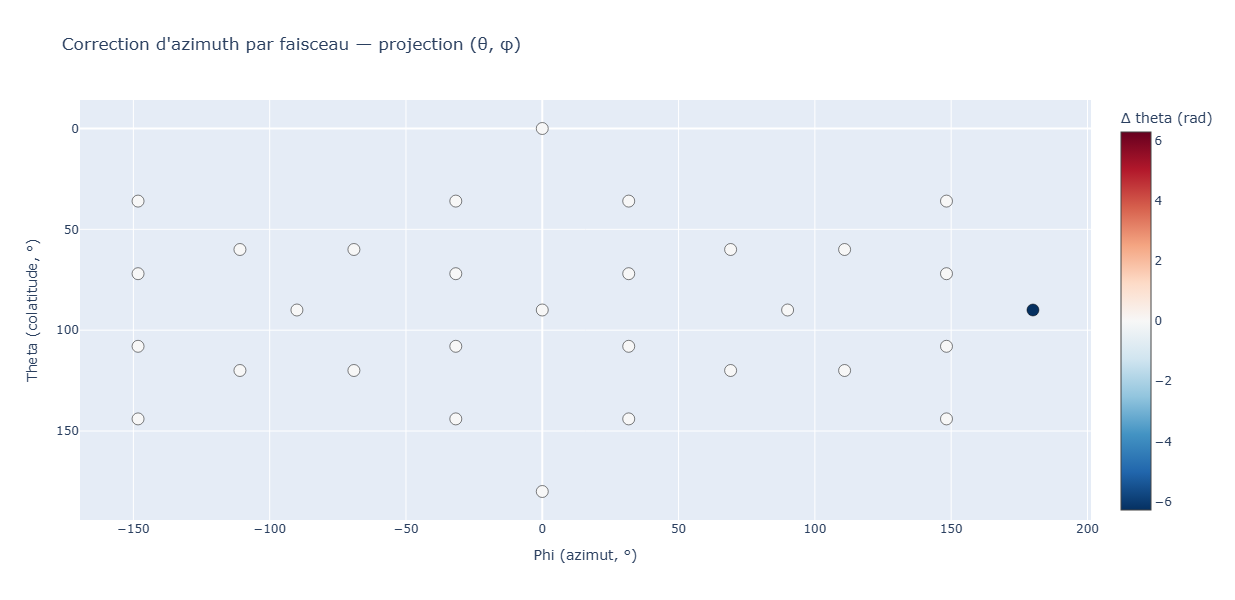

In [11]:
max_abs_delta = np.max(np.abs(delta_phi))

fig2 = go.Figure(data=go.Scatter(
    x=np.degrees(phi1),
    y=np.degrees(theta1),
    mode='markers',
    marker=dict(
        size=12,
        color=delta_phi,
        colorscale='RdBu_r',
        cmin=-max_abs_delta,
        cmax=max_abs_delta,
        colorbar=dict(title="Δ theta (rad)"),
        line=dict(color='black', width=0.5)
    ),
    text=[f"Faisceau {i}<br>Δphi = {np.degrees(delta_phi[i]):.4f} °<br>phi_avant={np.degrees(phi1[i]):.6g}<br>phi_après={np.degrees(phi2[i]):.6g}"
          for i in range(NBEAMS)],
    hoverinfo='text'
))
fig2.update_layout(
    title="Correction d'azimuth par faisceau — projection (θ, φ)",
    xaxis_title="Phi (azimut, °)",
    yaxis_title="Theta (colatitude, °)",
    yaxis=dict(autorange='reversed'),
    width=900,
    height=600
)
fig2.show()

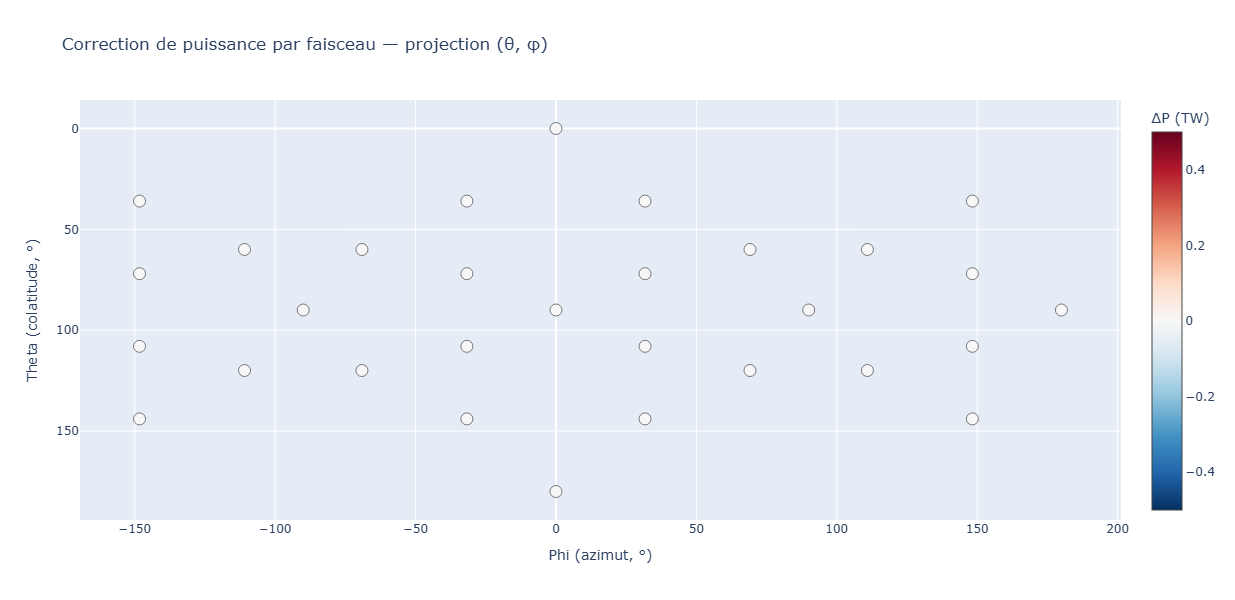

In [12]:
max_abs_delta = np.max(np.abs(delta_P0))

fig2 = go.Figure(data=go.Scatter(
    x=np.degrees(phi1),
    y=np.degrees(theta1),
    mode='markers',
    marker=dict(
        size=12,
        color=delta_P0,
        colorscale='RdBu_r',
        cmin=-max_abs_delta,
        cmax=max_abs_delta,
        colorbar=dict(title="ΔP (TW)"),
        line=dict(color='black', width=0.5)
    ),
    text=[f"Faisceau {i}<br>ΔP0 = {delta_P0[i]:.4f} TW <br>P0_avant={P0_1[i]:.6g}<br>P0_après={P0_2[i]:.6g}"
          for i in range(NBEAMS)],
    hoverinfo='text'
))
fig2.update_layout(
    title="Correction de puissance par faisceau — projection (θ, φ)",
    xaxis_title="Phi (azimut, °)",
    yaxis_title="Theta (colatitude, °)",
    yaxis=dict(autorange='reversed'),
    width=900,
    height=600
)
fig2.show()

# 5. Analyse des modes 

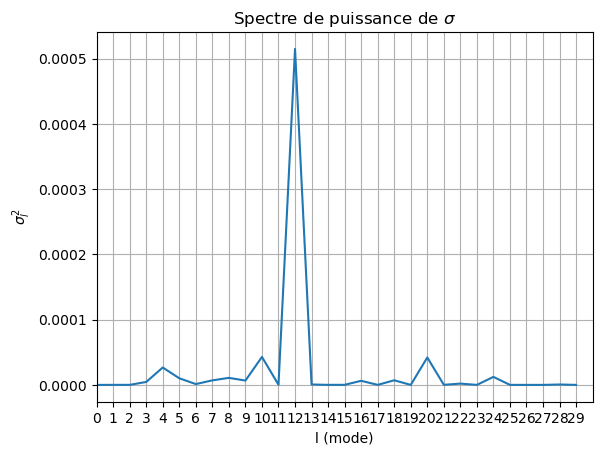

In [13]:
def plot_power_spectrum(dataset):
    def alms2power_spectrum(alms, LMAX):
        #Cette fonction calcule les $\sigma_{l}^2 / \bar{I}$
        the_modes = np.zeros(LMAX)
        the_modes_full = np.zeros((LMAX,LMAX+1))
        for l in range(LMAX):
            for m in range(l+1):
                the_modes_full[l,m] = np.real(alms[hp.sphtfunc.Alm.getidx(LMAX, l, m)]*
                    np.conjugate(alms[hp.sphtfunc.Alm.getidx(LMAX, l, m)]))
                if (m>0):
                    the_modes[l] = the_modes[l] + 2.*the_modes_full[l,m]
                else:          
                    the_modes[l] = the_modes[l] + the_modes_full[l,m]

        the_modes = the_modes / (4.*np.pi)
        return the_modes
    real_modes = dataset["real_modes"]
    imag_modes = dataset["imag_modes"]
    complex_modes = real_modes + 1j * imag_modes
    power_spectrum = alms2power_spectrum(complex_modes, LMAX)
    plt.plot(np.arange(LMAX), power_spectrum * 100.0)

LMAX = 30

fig = plt.figure()
ax = plt.axes()
ax.set_xticks(range(0, LMAX+1, 1))
plt.xlim([0, LMAX])
plt.title(r"Spectre de puissance de $\sigma$")
plt.xlabel("l (mode)")
plt.ylabel(r"$\sigma_l^2$")
plt.grid()
plt.xticks(np.arange(0, LMAX, 1))
plot_power_spectrum(dataset)

dict_keys(['avg_flux', 'real_modes', 'imag_modes', 'sigma_l^2', 'sigma_RMS %'])
0.2641092472781935
0.26409324754495217


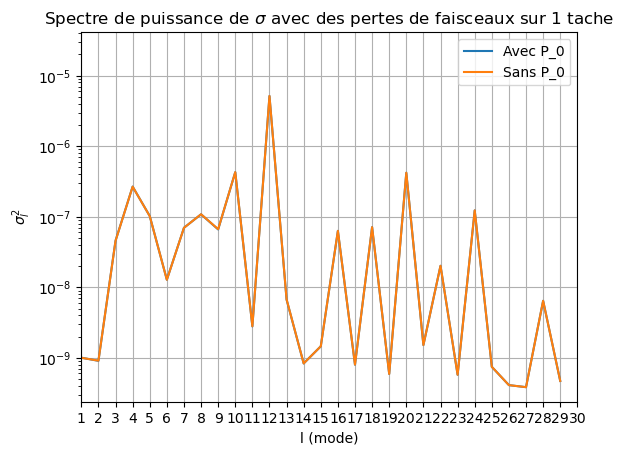

In [23]:
import matplotlib.pyplot as plt
import numpy as np
import pickle
import glob
import healpy as hp
import xarray as xr

def read_general_netcdf(filename):
    data = {}
    with xr.open_dataset(filename) as ds:
        for k, v in ds.data_vars.items():
            data[k] = v.values
        for k, v in ds.attrs.items():
            data[k] = v
    return data

def read_data(parameters):
    def imap_norm(intensity_map):
        avg_flux = np.mean(intensity_map)
        return intensity_map / avg_flux - 1.0, avg_flux

    def imap2modes(intensity_map_normalized, lmax):
        modes_complex = hp.sphtfunc.map2alm(intensity_map_normalized, lmax=lmax)
        return modes_complex.real, modes_complex.imag

    LMAX = 30
    illumination_evaluation_radii = 1940.0
    dataset = {}
    intensity_map = parameters["intensity"] * (illumination_evaluation_radii / 10000.0)**2
    intensity_map_normalized, dataset["avg_flux"] = imap_norm(intensity_map)
    dataset["real_modes"], dataset["imag_modes"] = imap2modes(intensity_map_normalized, LMAX)
    complex_modes = dataset["real_modes"] + 1j * dataset["imag_modes"]
    dataset["sigma_l^2"] = alms2power_spectrum(complex_modes, LMAX)
    dataset["sigma_RMS %"] = 100 * np.sqrt(np.sum(dataset["sigma_l^2"]))
    return dataset

def alms2power_spectrum(alms, LMAX):
    #Cette fonction calcule les $\sigma_{l}^2 / \bar{I}$
    the_modes = np.zeros(LMAX)
    the_modes_full = np.zeros((LMAX,LMAX+1))
    for l in range(LMAX):
        for m in range(l+1):
            the_modes_full[l,m] = np.real(alms[hp.sphtfunc.Alm.getidx(LMAX, l, m)]*
                np.conjugate(alms[hp.sphtfunc.Alm.getidx(LMAX, l, m)]))
            if (m>0):
                the_modes[l] = the_modes[l] + 2.*the_modes_full[l,m]
            else:          
                the_modes[l] = the_modes[l] + the_modes_full[l,m]

    the_modes = the_modes / (4.*np.pi)
    return the_modes

def plot_power_spectrum(dataset,label=None):
    real_modes = dataset["real_modes"]
    imag_modes = dataset["imag_modes"]
    complex_modes = real_modes + 1j * imag_modes
    power_spectrum = alms2power_spectrum(complex_modes, LMAX)
    plt.plot(np.arange(1, LMAX), power_spectrum[1:] ,label=label)


### Lecture des fichiers
p_in_z1z2_beam_all = read_general_netcdf("ifriit/p_in_z1z2_beam_all_opti1tache.nc")
dataset_compensated = read_data(p_in_z1z2_beam_all)

p_in_z1z2_beam_all_sansP0 = read_general_netcdf("ifriit/p_in_z1z2_beam_all_opti1tache_sansP0.nc")
dataset_compensated_sansP0 = read_data(p_in_z1z2_beam_all_sansP0)

print(dataset_compensated.keys())
print(dataset_compensated['sigma_RMS %'])
print(dataset_compensated_sansP0['sigma_RMS %'])


LMAX = 30
fig = plt.figure()
ax = plt.axes()
ax.set_xticks(range(0, LMAX+1, 1))
plt.xlim([0, LMAX])
plt.title(r"Spectre de puissance de $\sigma$ avec des pertes de faisceaux sur 1 tache")
plt.xlabel("l (mode)")
plt.ylabel(r"$\sigma_l^2$")

plot_power_spectrum(dataset_compensated, label="Avec P_0")
plot_power_spectrum(dataset_compensated_sansP0, label="Sans P_0")

plt.legend()
plt.legend(loc='upper right')
plt.grid()
plt.yscale('log')
ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin, ymax * 5)
plt.xlim([1, LMAX])
plt.xticks(np.arange(1, LMAX+1, 1))
plt.show()

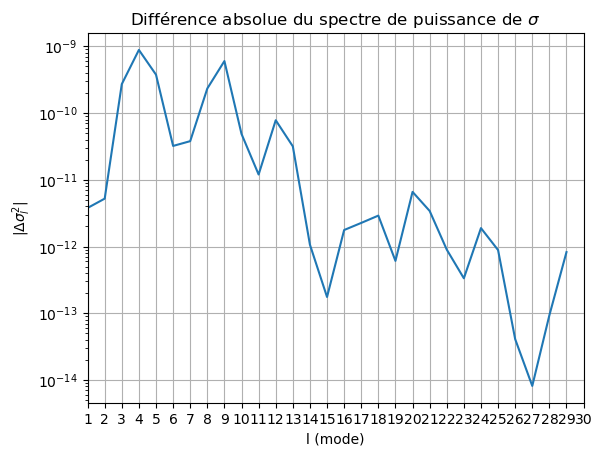

In [18]:
def get_power_spectrum(dataset):
    real_modes = dataset["real_modes"]
    imag_modes = dataset["imag_modes"]
    complex_modes = real_modes + 1j * imag_modes
    return alms2power_spectrum(complex_modes, LMAX)

LMAX = 30
ps_avec = get_power_spectrum(dataset_compensated)
ps_sans = get_power_spectrum(dataset_compensated_sansP0)
diff_abs = np.abs(ps_avec - ps_sans)

fig = plt.figure()
ax = plt.axes()
ax.set_xticks(range(0, LMAX+1, 1))
plt.xlim([1, LMAX])
plt.title(r"Différence absolue du spectre de puissance de $\sigma$")
plt.xlabel("l (mode)")
plt.ylabel(r"$|\Delta \sigma_l^2|$")
plt.plot(np.arange(1, LMAX), diff_abs[1:])
plt.grid()
plt.yscale('log')
plt.xticks(np.arange(1, LMAX+1, 1))
plt.savefig("diff_power_spectrum.png", dpi=300, bbox_inches='tight')
plt.show()